# A3 Roadwork Scheduler — Data Analysis

Find the best time windows to schedule highway construction on the A3, using real traffic count data from BASt (Bundesanstalt für Straßenwesen — Germany's federal road authority). Rather than guessing/estimating, we use 438,000+ hours of real hourly traffic counts across 45 stations on the A3, combined with Prophet time-series forecasting, to recommend specific dates, days and hours that minimize disruption.

This notebook documents every data decision made along the way, including a few mistakes we caught, fixed and noted.

## 1. Data Loading

### Picked 2019 and 2023

BASt publishes yearly hourly traffic count files per station. We deliberately excluded:
- **2020–2022**: COVID-19 caused highly abnormal traffic patterns (lockdowns, reduced commuting). Including these years would have distorted the "normal" weekly/seasonal pattern we're trying to model.
- **2022 specifically** also had very poor station coverage (only 16 of 45 stations had usable files), making it unreliable even setting COVID aside.

We used **2019** (pre-COVID baseline, 31 stations) and **2023** (most recent post-COVID normal year, 19 stations) to get **438,000 combined hourly records** across the full set of stations we could access.

First, we opened one station's file to check the column structure before writing a loader for all of them:

In [1]:
import pandas as pd

df = pd.read_csv('2019\\zst9033_2019.csv', sep=';', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (8760, 57)

Columns: ['TKNR', 'Zst', 'Land', 'Strklas', 'Strnum', 'Datum', 'Wotag', 'Fahrtzw', 'Stunde', 'KFZ_R1', 'K_KFZ_R1', 'KFZ_R2', 'K_KFZ_R2', 'Lkw_R1', 'K_Lkw_R1', 'Lkw_R2', 'K_Lkw_R2', 'PLZ_R1', 'K_PLZ_R1', 'Pkw_R1', 'K_Pkw_R1', 'Lfw_R1', 'K_Lfw_R1', 'Mot_R1', 'K_Mot_R1', 'PmA_R1', 'K_PmA_R1', 'Bus_R1', 'K_Bus_R1', 'LoA_R1', 'K_LoA_R1', 'Lzg_R1', 'K_Lzg_R1', 'Sat_R1', 'K_Sat_R1', 'Son_R1', 'K_Son_R1', 'PLZ_R2', 'K_PLZ_R2', 'Pkw_R2', 'K_Pkw_R2', 'Lfw_R2', 'K_Lfw_R2', 'Mot_R2', 'K_Mot_R2', 'PmA_R2', 'K_PmA_R2', 'Bus_R2', 'K_Bus_R2', 'LoA_R2', 'K_LoA_R2', 'Lzg_R2', 'K_Lzg_R2', 'Sat_R2', 'K_Sat_R2', 'Son_R2', 'K_Son_R2']

First 3 rows:


,TKNR,Zst,Land,Strklas,Strnum,Datum,Wotag,Fahrtzw,Stunde,KFZ_R1,...,Bus_R2,K_Bus_R2,LoA_R2,K_LoA_R2,Lzg_R2,K_Lzg_R2,Sat_R2,K_Sat_R2,Son_R2,K_Son_R2
0,6020,9033,9,A,3,190101,2,s,1,213,...,2,-,0,-,15,-,14,-,4,-
1,6020,9033,9,A,3,190101,2,s,2,396,...,0,-,0,-,8,-,8,-,1,-
2,6020,9033,9,A,3,190101,2,s,3,343,...,1,-,1,-,6,-,5,-,4,-


**Column meanings** (from BASt documentation):
- `Zst` — counting station ID
- `Datum` — date, format YYMMDD
- `Wotag` — weekday (1=Monday ... 7=Sunday)
- `Stunde` — hour of day (0–23)
- `KFZ_R1` / `KFZ_R2` — total motor vehicles in direction 1 / direction 2 (this already includes motorcycles — there's no need to separate them out, since `KFZ` means "Kraftfahrzeug" = any motor vehicle)
- `Lkw_R1` / `Lkw_R2` — trucks only, in each direction
- `PLZ` columns — motorcycle counts specifically (not postal code, despite the name) — we don't need this separately since it's already folded into `KFZ`

### Loading all stations, both years

In [2]:
import pandas as pd
import glob

def load_year(year):
    files = glob.glob(f'{year}\\*.csv')
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, sep=';', encoding='latin-1')
            df['year'] = year
            dfs.append(df)
        except Exception as e:
            print(f"Skipped {f}: {e}")
    return pd.concat(dfs, ignore_index=True)

df_2019 = load_year(2019)
df_2023 = load_year(2023)

df = pd.concat([df_2019, df_2023], ignore_index=True)

print(f"2019: {len(df_2019)} rows, {df_2019['Zst'].nunique()} stations")
print(f"2023: {len(df_2023)} rows, {df_2023['Zst'].nunique()} stations")
print(f"Total combined: {len(df)} rows")

2019: 271560 rows, 31 stations
2023: 166440 rows, 19 stations
Total combined: 438000 rows


Of the 45 A3 counting stations that exist, only 31 had usable 2019 files and 19 had usable 2023 files, due to broken/missing download links on BASt's portal for certain stations in certain years.

## 2. Cleaning & Feature Engineering

- Parse `Datum` into a real date
- Combine both directions into `total_traffic` and `total_trucks` (motorcycles are already included in `KFZ`, as noted above)
- Keep only the columns we actually need for scoring

In [3]:
# Parse date (format is YYMMDD)
df['Datum'] = pd.to_datetime(df['Datum'], format='%y%m%d')

# Total traffic both directions
df['total_traffic'] = df['KFZ_R1'] + df['KFZ_R2']
df['total_trucks'] = df['Lkw_R1'] + df['Lkw_R2']

# Keep what needed for analysis
df = df[['Datum', 'Wotag', 'Stunde', 'Zst', 'year',
         'total_traffic', 'total_trucks']]

print("Shape:", df.shape)
print("Date range:", df['Datum'].min(), "to", df['Datum'].max())
df.head(3)

Shape: (438000, 7)
Date range: 2019-01-01 00:00:00 to 2023-12-31 00:00:00


,Datum,Wotag,Stunde,Zst,year,total_traffic,total_trucks
0,2019-01-01,2,1,9010,2019,425,35
1,2019-01-01,2,2,9010,2019,440,29
2,2019-01-01,2,3,9010,2019,431,32


In [4]:
# Check which years are actually in the data
print(df['Datum'].dt.year.value_counts().sort_index())

Datum
2019    271560
2023    166440
Name: count, dtype: int64


## 3. Exploring the Weekly Pattern

A heatmap of average traffic by day-of-week × hour-of-day reveals the underlying pattern across the whole network — this is the foundation the scheduling recommendation is built on.

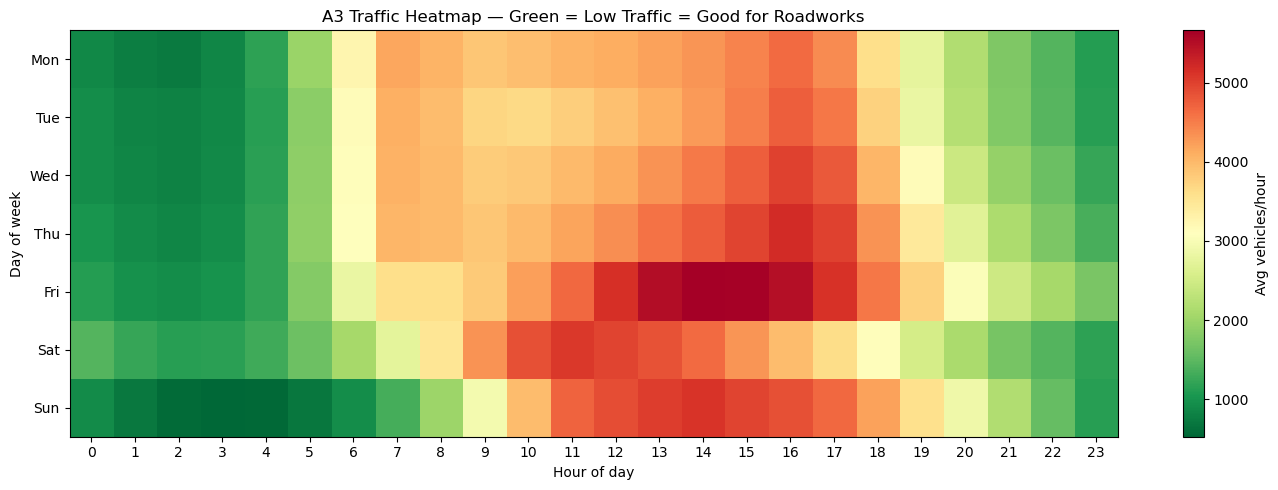

In [5]:
import matplotlib.pyplot as plt

heatmap = df.groupby(['Wotag', 'Stunde'])['total_traffic'].mean().unstack()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(14, 5))
plt.imshow(heatmap.values, aspect='auto', cmap='RdYlGn_r')
plt.colorbar(label='Avg vehicles/hour')
plt.yticks(range(7), days)
plt.xticks(range(24), range(24))
plt.xlabel('Hour of day')
plt.ylabel('Day of week')
plt.title('A3 Traffic Heatmap — Green = Low Traffic = Good for Roadworks')
plt.tight_layout()
plt.show()

**Finding:** Sunday early morning (roughly 2:00–6:00) is consistently the lowest-traffic window across the network. Friday afternoon (roughly 13:00–17:00) is consistently the worst.

## 4. Scoring Logic

We score every (weekday, hour) combination on two factors, combined in priority order:

1. **Congestion impact** (primary) — normalized traffic volume: `1 - (avg_traffic / max_traffic)`. Lower traffic → higher score.
2. **Freight/commuter impact** (secondary) — `1 - avg_truck_ratio`. Fewer trucks during that hour → higher score, since disrupting commercial freight has different consequences than disrupting regular commuters.

The two are **multiplied**, not averaged — a time slot only scores well if both factors are favorable. A low-traffic hour that happens to be truck-heavy gets pulled down, not just slightly discounted.

In [6]:
import pandas as pd

# Truck ratio per row
df['truck_ratio'] = df['total_trucks'] / df['total_traffic']

# Average traffic + truck ratio per hour/weekday combo
window_scores = df.groupby(['Wotag', 'Stunde']).agg(
    avg_traffic=('total_traffic', 'mean'),
    avg_truck_ratio=('truck_ratio', 'mean')
).reset_index()

# Score: lower traffic = higher score (normalize 0 to 1)
window_scores['traffic_score'] = 1 - (window_scores['avg_traffic'] / window_scores['avg_traffic'].max())

# Combine with truck ratio (fewer trucks = better)
window_scores['final_score'] = window_scores['traffic_score'] * (1 - window_scores['avg_truck_ratio'])

# Top 5 windows
days = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
window_scores['day_name'] = window_scores['Wotag'].map(days)

top5 = window_scores.sort_values('final_score', ascending=False).head(5)
print(top5[['day_name', 'Stunde', 'avg_traffic', 'avg_truck_ratio', 'final_score']])

    day_name  Stunde  avg_traffic  avg_truck_ratio  final_score
148      Sun       5   549.527682         0.092863     0.819066
147      Sun       4   528.348606         0.100961     0.815119
149      Sun       6   690.432990         0.074290     0.812791
146      Sun       3   582.903780         0.098623     0.808550
145      Sun       2   725.855670         0.087267     0.795685


In [7]:
# Compare best window vs worst window
worst = window_scores.sort_values('final_score').iloc[0]
best = window_scores.sort_values('final_score', ascending=False).iloc[0]

reduction_pct = (1 - best['avg_traffic']/worst['avg_traffic']) * 100

print(f"WORST window: {worst['day_name']} {int(worst['Stunde'])}:00 — {worst['avg_traffic']:.0f} vehicles/hour")
print(f"BEST window: {best['day_name']} {int(best['Stunde'])}:00 — {best['avg_traffic']:.0f} vehicles/hour")
print(f"\nReduction: {reduction_pct:.1f}% less traffic")

WORST window: Fri 15:00 — 5660 vehicles/hour
BEST window: Sun 5:00 — 550 vehicles/hour

Reduction: 90.3% less traffic


In [8]:
window_scores.to_csv('window_scores.csv', index=False)

## 5. CO2 Impact Estimation

**Assumption:** scheduling roadworks during a high-traffic window forces affected vehicles into a detour, estimated at ~2km extra driving. Average passenger car emissions are ~120g CO2/km, giving **0.24 kg CO2 per affected vehicle**. This is a simplification (real detours vary by location), but it gives a directionally meaningful, explainable estimate for comparing best vs. worst scheduling choices.

In [9]:
# Rough CO2 estimate
# Average car emits ~120g CO2/km, assume average disruption adds ~2km extra/detour per affected vehicle
vehicles_affected_worst = worst['avg_traffic']
vehicles_affected_best = best['avg_traffic']

co2_per_vehicle_kg = 0.12 * 2  # 120g/km * 2km extra = 0.24kg per vehicle

co2_worst = vehicles_affected_worst * co2_per_vehicle_kg
co2_best = vehicles_affected_best * co2_per_vehicle_kg

co2_saved = co2_worst - co2_best

print(f"CO2 if scheduled at worst time: {co2_worst:.1f} kg/hour")
print(f"CO2 if scheduled at best time: {co2_best:.1f} kg/hour")
print(f"CO2 saved per hour of roadwork: {co2_saved:.1f} kg")

CO2 if scheduled at worst time: 1358.4 kg/hour
CO2 if scheduled at best time: 131.9 kg/hour
CO2 saved per hour of roadwork: 1226.6 kg


## 6. Station Coordinates (for the network map)

Station coordinates come from a separate BASt file (`Jawe2022.csv`, the yearly-average traffic file), which also contains each station's UTM32 coordinates.

Note: first attempt assumed the coordinate strings just had German-style thousands-separator dots (e.g. `"502.145"` meaning `502145`), so we simply stripped the dots:

In [10]:
import pandas as pd
from pyproj import Transformer

coords = pd.read_csv('Jawe2022.csv', sep=';', encoding='latin-1')
coords = coords[['DZ_Nr', 'DZ_Name', 'Str_Kl', 'Str_Nr', 'Koor_UTM32_E', 'Koor_UTM32_N']]
coords = coords[(coords['Str_Kl'] == 'A') & (coords['Str_Nr'] == 3)]

# Fix the German number format (remove thousand-separator dots)
coords['Koor_UTM32_E'] = coords['Koor_UTM32_E'].astype(str).str.replace('.', '', regex=False).astype(float)
coords['Koor_UTM32_N'] = coords['Koor_UTM32_N'].astype(str).str.replace('.', '', regex=False).astype(float)

# Convert UTM32 -> WGS84 (lat/lon)
transformer = Transformer.from_crs("EPSG:25832", "EPSG:4326")
lat, lon = transformer.transform(coords['Koor_UTM32_E'].values, coords['Koor_UTM32_N'].values)

coords['lat'] = lat
coords['lon'] = lon

print(coords[['DZ_Nr', 'DZ_Name', 'lat', 'lon']])

    DZ_Nr                    DZ_Name        lat        lon
0    9033        AD Seligenstadt (O)  49.988271   9.029923
1    9011       AD Würzburg-West (O)  49.749310   9.837481
2    9034       AD Würzburg-West (W)  49.590070   2.851025
3    9046             AK Altdorf (S)  49.397955  11.305518
4    9038          AK Biebelried (O)  49.786465  10.159257
5    9036          AK Biebelried (W)  49.774285  10.079216
6    9093          AK Deggendorf (W)  48.821910  12.929774
7    9050      AK Fürth/Erlangen (O)  49.541156  11.022711
8    9951      AK Fürth/Erlangen (W)  49.560112  10.983059
9    9040            AK Nürnberg (O)  49.454155  11.255302
10   9039            AK Nürnberg (W)  49.466249  11.217928
11   9080          AK Regensburg (O)  48.991078  12.075362
12   9074          AK Regensburg (W)  48.995627  12.030329
13   9505       AS Aschaffenburg (W)  49.990085   9.060280
14   9508  AS Bessenbach-Waldaschaff  49.983969   9.261386
15   9519     AS Erlangen-Tennenlohe  49.390048   3.0033

**Problem found:** some resulting longitudes were far outside Bavaria (e.g. below 5°, which is near the French border, not Bavaria). The naive dot-stripping broke for values where the number of decimal-grouped digits didn't line up cleanly with simple removal.

In [11]:
problem_rows = coords[coords['lon'] < 5]  # anything under lon 5 is wrong for Bavaria
print(problem_rows[['DZ_Nr', 'DZ_Name']])

# Now check their RAW original UTM string values before our cleanup
raw = pd.read_csv('Jawe2022.csv', sep=';', encoding='latin-1')
raw = raw[raw['DZ_Nr'].isin(problem_rows['DZ_Nr'])]
print(raw[['DZ_Nr', 'DZ_Name', 'Koor_UTM32_E', 'Koor_UTM32_N']])

    DZ_Nr                 DZ_Name
2    9034    AD Würzburg-West (W)
15   9519  AS Erlangen-Tennenlohe
18   9507             AS Goldbach
25   9511    AS Wertheim/Lengfurt
27   9506        AS-Aschaffenburg
34   9051       Neumarkt/Opf. (S)
43   9627           Schlüsselfeld
44   9159           Würzburg-Kist
    DZ_Nr                 DZ_Name  Koor_UTM32_E Koor_UTM32_N
2    9034    AD Würzburg-West (W)        557.22    5.511.239
15   9519  AS Erlangen-Tennenlohe        649.44    5.488.130
18   9507             AS Goldbach        515.69    5.538.979
25   9511    AS Wertheim/Lengfurt        551.47    5.513.722
27   9506        AS-Aschaffenburg        511.47    5.537.681
34   9051       Neumarkt/Opf. (S)        680.23    5.465.451
43   9627           Schlüsselfeld        614.17    5.513.133
44   9159           Würzburg-Kist        564.01    5.511.123


### The actual fix

UTM coordinates use thousands-grouping in groups of 3 digits, but the *last* group can be shorter (e.g. representing decimal meters). A proper fix needs to re-pad each group to 3 digits except handle the final group's padding direction correctly — not just delete the separators.

In [12]:
import pandas as pd
from pyproj import Transformer

coords = pd.read_csv('Jawe2022.csv', sep=';', encoding='latin-1')
coords = coords[['DZ_Nr', 'DZ_Name', 'Str_Kl', 'Str_Nr', 'Koor_UTM32_E', 'Koor_UTM32_N',
                  'Fernziel_Ri1', 'Fernziel_Ri2']]
coords = coords[(coords['Str_Kl'] == 'A') & (coords['Str_Nr'] == 3)]

def fix_utm(value):
    # value comes in as string like '502.145' or '557.22'
    parts = str(value).split('.')
    # Rejoin all parts, but pad the LAST part to 3 digits (since UTM uses thousand-grouping in 3s)
    fixed = parts[0] + ''.join(p.ljust(3, '0') if i == len(parts)-1 else p.zfill(3)
                                 for i, p in enumerate(parts[1:], 1))
    return float(fixed)

coords['Koor_UTM32_E'] = coords['Koor_UTM32_E'].astype(str).apply(fix_utm)
coords['Koor_UTM32_N'] = coords['Koor_UTM32_N'].astype(str).apply(fix_utm)

transformer = Transformer.from_crs("EPSG:25832", "EPSG:4326")
lat, lon = transformer.transform(coords['Koor_UTM32_E'].values, coords['Koor_UTM32_N'].values)
coords['lat'] = lat
coords['lon'] = lon

print(coords[['DZ_Nr', 'DZ_Name', 'lat', 'lon']])

    DZ_Nr                    DZ_Name        lat        lon
0    9033        AD Seligenstadt (O)  49.988271   9.029923
1    9011       AD Würzburg-West (O)  49.749310   9.837481
2    9034       AD Würzburg-West (W)  49.750909   9.794322
3    9046             AK Altdorf (S)  49.397955  11.305518
4    9038          AK Biebelried (O)  49.786465  10.159257
5    9036          AK Biebelried (W)  49.774285  10.079216
6    9093          AK Deggendorf (W)  48.821910  12.929774
7    9050      AK Fürth/Erlangen (O)  49.541156  11.022711
8    9951      AK Fürth/Erlangen (W)  49.560112  10.983059
9    9040            AK Nürnberg (O)  49.454155  11.255302
10   9039            AK Nürnberg (W)  49.466249  11.217928
11   9080          AK Regensburg (O)  48.991078  12.075362
12   9074          AK Regensburg (W)  48.995627  12.030329
13   9505       AS Aschaffenburg (W)  49.990085   9.060280
14   9508  AS Bessenbach-Waldaschaff  49.983969   9.261386
15   9519     AS Erlangen-Tennenlohe  49.527345  11.0650

All coordinates now fall within the expected Bavaria/A3 range. We also kept `Fernziel_Ri1` / `Fernziel_Ri2` — the destination-city labels BASt assigns to each direction (e.g. "→ Frankfurt" vs "→ Würzburg") — used later in the app to let users pick which physical direction of traffic is affected by a closure, rather than always combining both directions.

## 7. Station Map

A quick static scatter plot to sanity-check coordinates, followed by an interactive Folium map (the same approach later embedded in the Streamlit app).

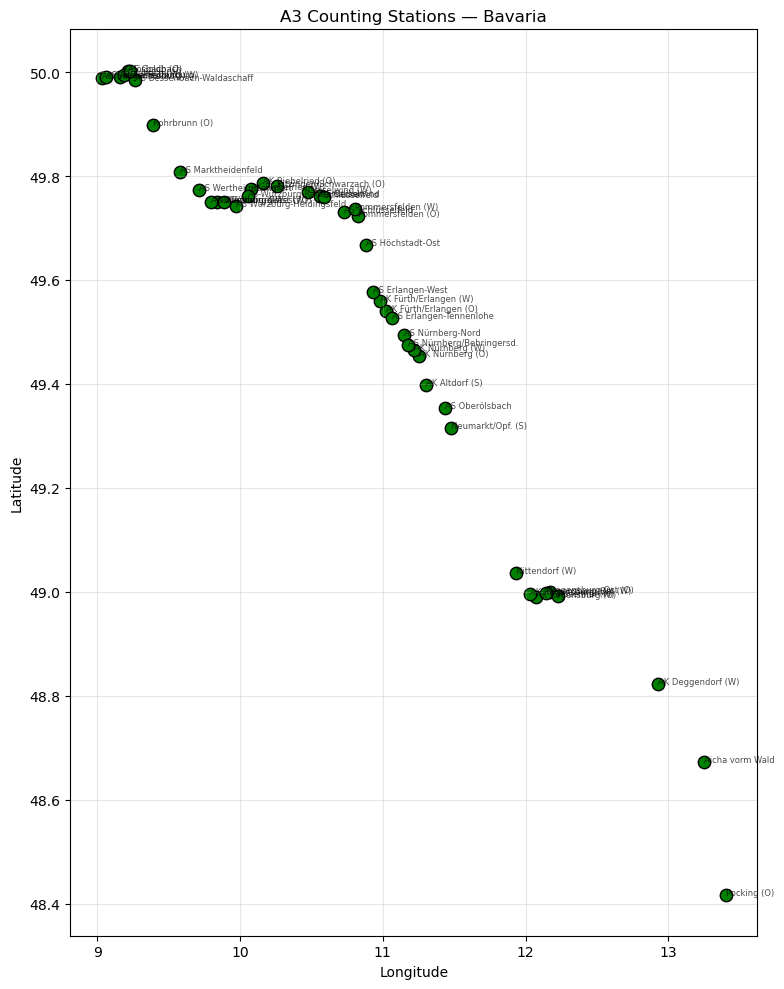

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.scatter(coords['lon'], coords['lat'], c='green', s=80, edgecolors='black')

for i, row in coords.iterrows():
    plt.annotate(row['DZ_Name'], (row['lon'], row['lat']), fontsize=6, alpha=0.7)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('A3 Counting Stations — Bavaria')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
import folium

# Center map roughly on Bavaria/A3 area
m = folium.Map(location=[49.6, 10.5], zoom_start=8)

for i, row in coords.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color='green',
        fill=True,
        fill_color='green',
        popup=row['DZ_Name']
    ).add_to(m)

m.save('a3_map.html')
m

## 8. West → East Strip View

The dot map is fine, but it doesn't read like a route. This sorts stations by longitude and lays them out left to right (Frankfurt-side → Passau-side), colored by traffic — closer to what the whiteboard plan asked for as a "kilometer-based heat-map".

In [15]:
# Rebuild station traffic averages
station_avg = df.groupby('Zst')['total_traffic'].mean().reset_index()
station_avg.columns = ['DZ_Nr', 'avg_traffic']

# Merge with coordinates
coords_with_traffic = coords.merge(station_avg, on='DZ_Nr', how='left')

# Sort by longitude = west to east along A3
coords_with_traffic_sorted = coords_with_traffic.sort_values('lon').reset_index(drop=True)
coords_with_traffic_sorted['route_position'] = range(len(coords_with_traffic_sorted))

print(coords_with_traffic_sorted[['DZ_Name', 'lon', 'avg_traffic', 'route_position']])

                      DZ_Name        lon  avg_traffic  route_position
0         AD Seligenstadt (O)   9.029923  4038.679509               0
1        AS Aschaffenburg (W)   9.060280          NaN               1
2            AS-Aschaffenburg   9.160017          NaN               2
3                Goldbach (W)   9.185152  3855.361073               3
4                 AS Goldbach   9.218942  3887.457591               4
5                 Hösbach (O)   9.229139  3120.875799               5
6   AS Bessenbach-Waldaschaff   9.261386  2958.377854               6
7               Rohrbrunn (O)   9.391617          NaN               7
8          AS Marktheidenfeld   9.582233          NaN               8
9        AS Wertheim/Lengfurt   9.714836  2828.451256               9
10       AD Würzburg-West (W)   9.794322  2863.458447              10
11       AD Würzburg-West (O)   9.837481  3727.659989              11
12              Würzburg-Kist   9.888549  3780.224543              12
13   AS Würzburg-Hei

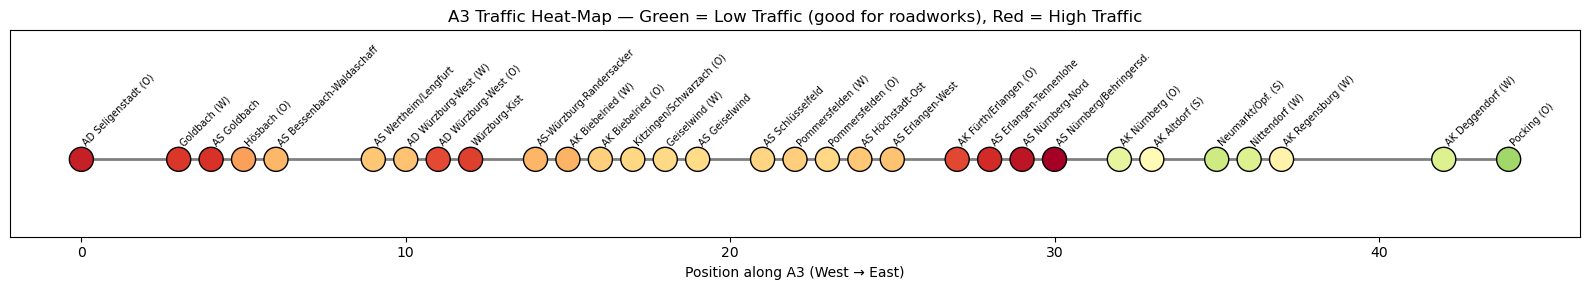

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plot_data = coords_with_traffic_sorted.dropna(subset=['avg_traffic']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 3))

norm_traffic = plot_data['avg_traffic'] / plot_data['avg_traffic'].max()
colors = cm.RdYlGn_r(norm_traffic)  # red = high traffic, green = low traffic

ax.scatter(plot_data['route_position'], [0]*len(plot_data), c=colors, s=300, edgecolors='black', zorder=3)
ax.plot(plot_data['route_position'], [0]*len(plot_data), color='gray', zorder=1, linewidth=2)

for i, row in plot_data.iterrows():
    ax.annotate(row['DZ_Name'], (row['route_position'], 0.05), rotation=45, fontsize=7, ha='left')

ax.set_yticks([])
ax.set_xlabel('Position along A3 (West → East)')
ax.set_title('A3 Traffic Heat-Map — Green = Low Traffic (good for roadworks), Red = High Traffic')
ax.set_ylim(-0.3, 0.5)
plt.tight_layout()
plt.show()

## 9. Per-Station Best Windows

Section 4's scoring used the whole network averaged together. Every station has its own traffic pattern though, so here we score each station against its own range instead of the global one, and pull out each station's individual best window.

In [17]:
# For each station, find its own best time window (not just overall average)
station_window_scores = df.groupby(['Zst', 'Wotag', 'Stunde']).agg(
    avg_traffic=('total_traffic', 'mean'),
    avg_trucks=('total_trucks', 'mean')
).reset_index()

station_window_scores['truck_ratio'] = station_window_scores['avg_trucks'] / station_window_scores['avg_traffic']

# Normalize score per station (so each station is compared to its OWN range, not global)
def normalize_per_station(group):
    group['score'] = 1 - (group['avg_traffic'] / group['avg_traffic'].max())
    return group

station_window_scores = station_window_scores.groupby('Zst', group_keys=False).apply(normalize_per_station)
station_window_scores['final_score'] = station_window_scores['score'] * (1 - station_window_scores['truck_ratio'])

# Get the single BEST window per station
best_per_station = station_window_scores.loc[
    station_window_scores.groupby('Zst')['final_score'].idxmax()
].reset_index(drop=True)

days_map = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
best_per_station['day_name'] = best_per_station['Wotag'].map(days_map)

# Merge with station names
best_per_station = best_per_station.merge(coords[['DZ_Nr','DZ_Name']], left_on='Zst', right_on='DZ_Nr', how='left')

print(best_per_station[['DZ_Name','day_name','Stunde','avg_traffic','final_score']])

                      DZ_Name day_name  Stunde  avg_traffic  final_score
0                 Hösbach (O)      Sun       5   552.676190     0.841111
1        AD Würzburg-West (O)      Sun       5   595.971429     0.838583
2    Kitzingen/Schwarzach (O)      Sun       5   559.423077     0.801026
3         AD Seligenstadt (O)      Sun       5   734.590476     0.853663
4        AD Würzburg-West (W)      Sun       5   514.438095     0.835496
5           AK Biebelried (W)      Sun       5   525.247619     0.826762
6           AK Biebelried (O)      Sun       5   518.692308     0.824582
7             AK Nürnberg (O)      Sun       5   382.933333     0.835230
8              Geiselwind (W)      Sun       5   557.653846     0.793882
9              AK Altdorf (S)      Sun       4   472.442308     0.826918
10      AK Fürth/Erlangen (O)      Sun       5   647.371429     0.862324
11          Neumarkt/Opf. (S)      Sun       4   394.923810     0.804613
12          AK Regensburg (W)      Sun       5   45

C:\Users\fikre\AppData\Local\Temp\ipykernel_24364\2833182592.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_window_scores = station_window_scores.groupby('Zst', group_keys=False).apply(normalize_per_station)


A quick function to pull the top 3 windows for any single station, with CO2 and truck ratio included — this is basically the logic that later became the app's core recommendation.

In [18]:
def recommend_window(station_id, duration_hours=6):
    station_data = station_window_scores[station_window_scores['Zst'] == station_id].copy()
    station_data['day_name'] = station_data['Wotag'].map(days_map)

    top3 = station_data.sort_values('final_score', ascending=False).head(3)
    station_name = coords[coords['DZ_Nr']==station_id]['DZ_Name'].values[0]

    print(f"📍 {station_name} — construction duration: {duration_hours}h\n")

    for rank, (i, row) in enumerate(top3.iterrows(), 1):
        co2 = row['avg_traffic'] * 0.24 * duration_hours
        print(f"{rank}. {row['day_name']} {int(row['Stunde'])}:00 (score {row['final_score']:.2f})")
        print(f"   → {row['avg_traffic']:.0f} vehicles/hr, {row['truck_ratio']*100:.0f}% trucks")
        print(f"   → Estimated CO2 impact: {co2:.0f} kg over {duration_hours}h\n")

    return top3

recommend_window(station_id=9033, duration_hours=6)

📍 AD Seligenstadt (O) — construction duration: 6h

1. Sun 5:00 (score 0.85)
   → 735 vehicles/hr, 6% trucks
   → Estimated CO2 impact: 1058 kg over 6h

2. Sun 4:00 (score 0.85)
   → 701 vehicles/hr, 7% trucks
   → Estimated CO2 impact: 1009 kg over 6h

3. Sun 6:00 (score 0.84)
   → 942 vehicles/hr, 4% trucks
   → Estimated CO2 impact: 1356 kg over 6h



,Zst,Wotag,Stunde,avg_traffic,avg_trucks,truck_ratio,score,final_score,day_name
652,9033,7,5,734.590476,42.895238,0.058393,0.906603,0.853663,Sun
651,9033,7,4,700.923810,46.952381,0.066986,0.910883,0.849866,Sun
653,9033,7,6,941.980952,40.466667,0.042959,0.880235,0.842420,Sun


## 10. Splitting by Direction

`total_traffic` sums both directions, but a roadwork project might only close one side. BASt's `Jawe2022.csv` includes `Fernziel_Ri1` / `Fernziel_Ri2` — the actual destination city for each direction at each station — so we can use real labels instead of generic "Direction 1 / 2".

In [19]:
# Separate the two directions instead of summing them
direction_data = []

for f in glob.glob('2019\\*.csv') + glob.glob('2023\\*.csv'):
    try:
        d = pd.read_csv(f, sep=';', encoding='latin-1')
        direction_data.append(d)
    except Exception as e:
        print(f"Skipped {f}: {e}")

df_dir = pd.concat(direction_data, ignore_index=True)
df_dir['Datum'] = pd.to_datetime(df_dir['Datum'], format='%y%m%d')

# Keep R1 and R2 SEPARATE (not summed)
df_dir = df_dir[['Datum', 'Wotag', 'Stunde', 'Zst', 'KFZ_R1', 'KFZ_R2', 'Lkw_R1', 'Lkw_R2']]

print(df_dir.shape)
print(df_dir.head())

(438000, 8)
       Datum  Wotag  Stunde   Zst  KFZ_R1  KFZ_R2  Lkw_R1  Lkw_R2
0 2019-01-01      2       1  9010     304     121      20      15
1 2019-01-01      2       2  9010     229     211      18      11
2 2019-01-01      2       3  9010     193     238      22      10
3 2019-01-01      2       4  9010     171     193      25       9
4 2019-01-01      2       5  9010     146     152      20      14


In [20]:
raw_coords = pd.read_csv('Jawe2022.csv', sep=';', encoding='latin-1')
print(raw_coords[['DZ_Name', 'Fernziel_Ri1', 'Fernziel_Ri2']].head(10))

                 DZ_Name       Fernziel_Ri1 Fernziel_Ri2
0    AD Seligenstadt (O)  Frankfurt a. Main     Würzburg
1   AD Würzburg-West (O)  Frankfurt a. Main     Würzburg
2   AD Würzburg-West (W)  Frankfurt a. Main     Würzburg
3         AK Altdorf (S)           Nürnberg       Passau
4      AK Biebelried (O)           Würzburg     Nürnberg
5      AK Biebelried (W)           Würzburg     Nürnberg
6      AK Deggendorf (W)           Nürnberg       Passau
7  AK Fürth/Erlangen (O)           Würzburg     Nürnberg
8  AK Fürth/Erlangen (W)           Würzburg     Nürnberg
9        AK Nürnberg (O)           Nürnberg       Passau


In [21]:
# Merge direction labels into the traffic data
direction_labels = pd.read_csv('Jawe2022.csv', sep=';', encoding='latin-1')
direction_labels = direction_labels[['DZ_Nr', 'Fernziel_Ri1', 'Fernziel_Ri2']]

df_dir = df_dir.merge(direction_labels, left_on='Zst', right_on='DZ_Nr', how='left')

# Now we can analyze each direction separately
r1_avg = df_dir.groupby('Zst')['KFZ_R1'].mean().reset_index(name='avg_R1')
r2_avg = df_dir.groupby('Zst')['KFZ_R2'].mean().reset_index(name='avg_R2')

direction_compare = r1_avg.merge(r2_avg, on='Zst').merge(direction_labels, left_on='Zst', right_on='DZ_Nr')
print(direction_compare[['DZ_Nr','Fernziel_Ri1','avg_R1','Fernziel_Ri2','avg_R2']])

    DZ_Nr       Fernziel_Ri1       avg_R1 Fernziel_Ri2       avg_R2
0    9010  Frankfurt a. Main  1554.063242     Würzburg  1566.812557
1    9011  Frankfurt a. Main  1884.415925     Würzburg  1843.244064
2    9027           Würzburg  1324.624658     Nürnberg  1340.668493
3    9033  Frankfurt a. Main  1937.370263     Würzburg  2101.309247
4    9034  Frankfurt a. Main  1437.729110     Würzburg  1425.729338
5    9036           Würzburg  1489.020091     Nürnberg  1498.523687
6    9038           Würzburg  1358.575457     Nürnberg  1387.455365
7    9040           Nürnberg   957.343664       Passau   954.009874
8    9041           Würzburg  1324.525457     Nürnberg  1326.412671
9    9046           Nürnberg  1114.865297       Passau  1139.462100
10   9050           Würzburg  1805.738470     Nürnberg  1930.008048
11   9051           Nürnberg   793.682820       Passau   835.294977
12   9074           Nürnberg  1169.250913       Passau  1155.166724
13   9081           Nürnberg   867.360559       

Both directions turn out fairly close at most stations (within ~5-10%), which makes sense for a through-route — so direction-splitting doesn't change the headline recommendation much, but it does let the app correctly answer "which side of the road is affected" with real city names instead of generic labels.

## 11. Seasonal Forecasting with Prophet

Everything above is a historical average — it tells you the best recurring weekly slot, but not whether a *long* project (weeks or months) should be shifted to a quieter season. For that we use Prophet, fit per-station on the full hourly time series, to get a forecasted monthly traffic pattern.

First test on a single station to confirm the time series is shaped correctly:

In [22]:
from prophet import Prophet

def prepare_station_series(station_id):
    station_df = df[df['Zst'] == station_id].copy()
    station_df['ds'] = station_df['Datum'] + pd.to_timedelta(station_df['Stunde'], unit='h')
    station_df = station_df[['ds', 'total_traffic']].rename(columns={'total_traffic': 'y'})
    station_df = station_df.sort_values('ds').reset_index(drop=True)
    return station_df

test_series = prepare_station_series(9033)
print(test_series.shape)
print(test_series.head())
print(test_series.tail())

(17520, 2)
                   ds    y
0 2019-01-01 01:00:00  389
1 2019-01-01 02:00:00  799
2 2019-01-01 03:00:00  795
3 2019-01-01 04:00:00  634
4 2019-01-01 05:00:00  479
                       ds     y
17515 2023-12-31 20:00:00  2281
17516 2023-12-31 21:00:00  1845
17517 2023-12-31 22:00:00  1411
17518 2023-12-31 23:00:00  1087
17519 2024-01-01 00:00:00   814


In [23]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
model.fit(test_series)

# Forecast 1 year ahead (8760 hours)
future = model.make_future_dataframe(periods=8760, freq='h')
forecast = model.predict(future)

# Prophet can predict negative values in low-traffic hours — clip them to 0
forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

12:41:10 - cmdstanpy - INFO - Chain [1] start processing
12:41:18 - cmdstanpy - INFO - Chain [1] done processing


                       ds         yhat   yhat_lower   yhat_upper
26270 2024-12-30 15:00:00  4168.842575  3118.138702  5213.292459
26271 2024-12-30 16:00:00  4381.926935  3310.799940  5398.031982
26272 2024-12-30 17:00:00  4417.837835  3334.200856  5475.675437
26273 2024-12-30 18:00:00  4118.136699  2975.906709  5182.734550
26274 2024-12-30 19:00:00  3377.920654  2385.096716  4429.089597
26275 2024-12-30 20:00:00  2283.648827  1209.678653  3230.593223
26276 2024-12-30 21:00:00  1124.257051    19.589179  2119.805667
26277 2024-12-30 22:00:00   219.808680     0.000000  1267.106675
26278 2024-12-30 23:00:00     0.000000     0.000000   780.305514
26279 2024-12-31 00:00:00     0.000000     0.000000   412.895368


In [24]:
# Filter only future predictions (beyond the last real data point)
future_only = forecast[forecast['ds'] > test_series['ds'].max()].copy()
future_only['month'] = future_only['ds'].dt.month
future_only['day_of_week'] = future_only['ds'].dt.dayofweek
future_only['hour'] = future_only['ds'].dt.hour

# Best months by forecasted traffic
monthly_best = future_only.groupby('month')['yhat'].mean().sort_values()
print("Best months (lowest predicted traffic):")
print(monthly_best)

Best months (lowest predicted traffic):
month
12    2255.087369
11    2361.062700
10    2710.515086
1     2810.099621
9     2887.032383
6     2941.678728
2     2964.916149
5     2981.537274
8     3040.921865
3     3072.415105
4     3090.326139
7     3225.309924
Name: yhat, dtype: float64


**Finding:** July consistently comes out as the highest-traffic month, with November/December/January consistently the lowest — same shape held across almost every station once we scaled this up to all of them.

### Running Prophet across every station

One fit takes roughly 1-3 minutes, so this isn't something the live app can do on demand. it's run once here and the monthly results get saved to `prophet_results.json`, which the app then just loads. 13 of the 45 stations failed or didn't have enough data to fit, the rest (32) made it through.

The full per-station forecasting loop (looping over every station, fitting Prophet, and saving `prophet_results.json`) now lives in `refresh_forecasts.py`, so it can be re-run on its own whenever new yearly data is added, without reopening this notebook.

## Summary of Key Findings

- **Best general window:** Sunday early morning (~02:00–06:00) — lowest traffic and lowest truck ratio across nearly all stations
- **Worst general window:** Friday afternoon (~13:00–17:00)
- **Typical reduction:** choosing the best window over the worst can reduce traffic exposure by **85–93%**, depending on station
- **Seasonal pattern (Prophet):** July is consistently the highest-traffic month network-wide; November/December/January are consistently the lowest
- **Direction:** both directions are fairly balanced at most stations, but real destination labels (`Fernziel_Ri1/Ri2`) let the app ask "which side is affected" properly
- **Data coverage:** 32 of 45 A3 stations had usable traffic data across 2019+2023; the same 32 (roughly) made it through Prophet forecasting successfully
- **Why 2019+2023 only:** COVID-affected years (2020–2022) were excluded as non-representative of normal traffic patterns

This analysis feeds directly into the Streamlit app (`app.py`), which lets a user pick a station, direction, duration, and working hours, and returns a specific recommended date range with supporting reasoning.